<a href="https://colab.research.google.com/github/changsin/polysemy_xlang_wsi/blob/main/robustness_checks_kjv_cuv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Robustness Checks

## 5.2 Robustness check

This section of the notebook performs a **robustness check** to ensure that the observed differences in polysemy between English and Chinese lemmas are not an artifact of comparing potentially dissimilar sets of words.

Here's what the robustness check entails:

1.  **Identifying Co-occurrence Pairs**: The first step is to identify "lemma co-occurrence pairs". These are pairs of English and Chinese lemmas that appear together in the same 'verse_id' (e.g., the same biblical verse). For instance, if the English lemma 'love' and the Chinese lemma '爱' (ài) both appear in verse John 3:16, they form a co-occurrence pair for that verse.

2.  **Counting Co-occurrences**: The code then counts how many times each unique (English lemma, Chinese lemma) pair co-occurs across all verses. This gives a measure of how strongly associated these cross-lingual lemma pairs are.

3.  **Filtering for Strong Overlaps**: To focus on robust comparisons, only pairs that co-occur at least 10 times are retained. These are considered "strong overlaps" and form the basis for the subsequent analysis.

4.  **Restricting WSI Results**: The next step restricts the Word Sense Induction (WSI) results for both English and Chinese to include *only* those lemmas that participated in these strong co-occurrence pairs. This ensures that the comparison is made on a set of lemmas that have clear cross-lingual counterparts.

5.  **Re-running Statistical Tests**: Finally, the Mann-Whitney U test and the frequency-stratified comparison (which were previously run on the full sets of lemmas) are re-executed, but this time only on the filtered sets of overlapping lemmas. This verifies if the significant differences in polysemy between English and Chinese persist even when controlling for cross-lingual co-occurrence.

In essence, the robustness check aims to strengthen the confidence in the findings by ensuring they hold under more stringent comparison conditions, specifically by focusing on lemmas that are directly comparable across languages due to their shared textual context.

## 5.2.0 Load data

Upload the following files under `bible_data`:
- enlgish_wsi_results.csv
- chinese_wsi_results.csv
- english_sense_labels.csv
- chinese_sense_labels.csv
- english_embeddings.npz
- chinese_embeddings.npz

In [1]:
import pandas as pd
from pathlib import Path
DATA_DIR = Path("/content") / "bible_data"
OUTPUT_DIR = Path("/content") / "output"
FIG_DIR    = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

# Load the WSI results for English and Chinese, if not already loaded
en = pd.read_csv(DATA_DIR / "english_wsi_results.csv")
zh = pd.read_csv(DATA_DIR / "chinese_wsi_results.csv")

# Load per-instance sense labels
en_labels = pd.read_csv(DATA_DIR / "english_sense_labels.csv")
zh_labels = pd.read_csv(DATA_DIR / "chinese_sense_labels.csv")

### 5.2.1 Build lemma co-occurence pairs

In [2]:
print("\n" + "="*60)
print("Step 8: Overlap-Only Robustness Check")
print("="*60)

# Load per-instance sense labels
en_labels = pd.read_csv(DATA_DIR / "english_sense_labels.csv")
zh_labels = pd.read_csv(DATA_DIR / "chinese_sense_labels.csv")

# Merge on verse_id to get co-occurring lemmas
merged = en_labels.merge(
    zh_labels,
    on="verse_id",
    suffixes=("_en", "_zh")
)

# Count lemma co-occurrence pairs
pair_counts = (
    merged.groupby(["lemma_en", "lemma_zh"])
    .size()
    .reset_index(name="co_occurrences")
)

# Keep only strong overlaps (at least 10 shared verses)
pair_counts = pair_counts[pair_counts["co_occurrences"] >= 10]

print(f"Total aligned lemma pairs: {len(pair_counts)}")


Step 8: Overlap-Only Robustness Check
Total aligned lemma pairs: 5133


### 5.2.2 Identify overlapping lemma sets

In [3]:
# Lemmas that participate in aligned pairs
en_overlap = set(pair_counts["lemma_en"])
zh_overlap = set(pair_counts["lemma_zh"])

print(f"English overlapping lemmas: {len(en_overlap)}")
print(f"Chinese overlapping lemmas: {len(zh_overlap)}")

English overlapping lemmas: 576
Chinese overlapping lemmas: 484


5.2.3 Restrict WSI results to overlap lemmas only

In [4]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("/content") / "bible_data"

en = pd.read_csv(DATA_DIR / "english_wsi_results.csv")
zh = pd.read_csv(DATA_DIR / "chinese_wsi_results.csv")

# Rename 'k_ward' to 'k_hdbscan' for English to match Chinese data and allow comparison
# This is a workaround for missing 'k_hdbscan' in the English WSI results file.
if 'k_hdbscan' not in en.columns and 'k_ward' in en.columns:
    en = en.rename(columns={'k_ward': 'k_hdbscan'})

en_overlap_df = en[en["lemma"].isin(en_overlap)]
zh_overlap_df = zh[zh["lemma"].isin(zh_overlap)]

print(f"Filtered EN lemmas: {len(en_overlap_df)}")
print(f"Filtered ZH lemmas: {len(zh_overlap_df)}")

Filtered EN lemmas: 576
Filtered ZH lemmas: 484


### 5.2.4 Run Mann-Whitney on overlap only

In [5]:
from scipy.stats import mannwhitneyu

U, p = mannwhitneyu(
    en_overlap_df["k_hdbscan"],
    zh_overlap_df["k_hdbscan"],
    alternative="two-sided"
)

print("\n── Overlap-Only Statistical Comparison ──")
print(f"EN mean k: {en_overlap_df['k_hdbscan'].mean():.3f}")
print(f"ZH mean k: {zh_overlap_df['k_hdbscan'].mean():.3f}")
print(f"p-value: {p:.6f}")


── Overlap-Only Statistical Comparison ──
EN mean k: 1.891
ZH mean k: 1.233
p-value: 0.000000


In [6]:
print("\n" + "="*60)
print("Frequency-Matched Polysemy Comparison (Overlap Only)")
print("="*60)

# Define bins
bins = [30, 60, 100, 200, 500, 1000]
labels = ["30–59", "60–99", "100–199", "200–499", "500+"]

def assign_bin(n):
    for i in range(len(bins)-1):
        if bins[i] <= n < bins[i+1]:
            return labels[i]
    if n >= bins[-1]:
        return labels[-1]
    return None

# Assign bins to overlap dataframes directly
en_overlap_df = en_overlap_df.copy()
zh_overlap_df = zh_overlap_df.copy()

en_overlap_df["freq_bin"] = en_overlap_df["n_instances"].apply(assign_bin)
zh_overlap_df["freq_bin"] = zh_overlap_df["n_instances"].apply(assign_bin)

# Remove words outside bins
en_bin_overlap_df = en_overlap_df.dropna(subset=["freq_bin"])
zh_bin_overlap_df = zh_overlap_df.dropna(subset=["freq_bin"])

bin_results = []

for bin_label in labels:
    en_subset = en_bin_overlap_df[
        en_bin_overlap_df["freq_bin"] == bin_label
    ]["k_hdbscan"]

    zh_subset = zh_bin_overlap_df[
        zh_bin_overlap_df["freq_bin"] == bin_label
    ]["k_hdbscan"]

    if len(en_subset) < 5 or len(zh_subset) < 5:
        continue

    from scipy.stats import mannwhitneyu
    U, p = mannwhitneyu(en_subset, zh_subset, alternative="two-sided")

    bin_results.append({
        "freq_bin": bin_label,
        "en_mean_k": en_subset.mean(),
        "zh_mean_k": zh_subset.mean(),
        "n_en": len(en_subset),
        "n_zh": len(zh_subset),
        "p_value": p
    })

bin_df = pd.DataFrame(bin_results)

print("\n── Frequency-Stratified Results (Overlap Only) ──")
print(bin_df)

bin_df.to_csv(
    OUTPUT_DIR / "frequency_matched_comparison_overlap_df.csv",
    index=False
)


Frequency-Matched Polysemy Comparison (Overlap Only)

── Frequency-Stratified Results (Overlap Only) ──
  freq_bin  en_mean_k  zh_mean_k  n_en  n_zh       p_value
0    30–59   1.432039   1.091787   206   207  3.385722e-13
1    60–99   1.702899   1.274194   138   124  6.928065e-09
2  100–199   1.939655   1.344828   116    87  2.545135e-09
3  200–499   2.963415   1.460000    82    50  4.244432e-08
4     500+   2.676471   1.437500    34    16  6.267420e-05


In [7]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("/content") / "bible_data"
OUTPUT_DIR = Path("/content") / "output"
FIG_DIR    = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

print("\n" + "="*60)
print("Frequency-Matched Polysemy Comparison (All Nouns)")
print("="*60)

# Define bins (copy from previous cell)
bins = [30, 60, 100, 200, 500, 1000]
labels = ["30–59", "60–99", "100–199", "200–499", "500+"]

def assign_bin(n):
    for i in range(len(bins)-1):
        if bins[i] <= n < bins[i+1]:
            return labels[i]
    if n >= bins[-1]:
        return labels[-1]
    return None

# Load the WSI results for English and Chinese, if not already loaded (to ensure we use full data)
en = pd.read_csv(DATA_DIR / "english_wsi_results.csv")
zh = pd.read_csv(DATA_DIR / "chinese_wsi_results.csv")

# Rename 'k_ward' to 'k_hdbscan' for English to match Chinese data and allow comparison
# This is a workaround for missing 'k_hdbscan' in the English WSI results file.
if 'k_hdbscan' not in en.columns and 'k_ward' in en.columns:
    en = en.rename(columns={'k_ward': 'k_hdbscan'})

# Assign bins to the full dataframes
en_all_df = en.copy()
zh_all_df = zh.copy()

en_all_df["freq_bin"] = en_all_df["n_instances"].apply(assign_bin)
zh_all_df["freq_bin"] = zh_all_df["n_instances"].apply(assign_bin)

# Remove words outside bins
en_bin_all_df = en_all_df.dropna(subset=["freq_bin"])
zh_bin_all_df = zh_all_df.dropna(subset=["freq_bin"])

bin_results_all = []

for bin_label in labels:
    en_subset = en_bin_all_df[
        en_bin_all_df["freq_bin"] == bin_label
    ]["k_hdbscan"]

    zh_subset = zh_bin_all_df[
        zh_bin_all_df["freq_bin"] == bin_label
    ]["k_hdbscan"]

    if len(en_subset) < 5 or len(zh_subset) < 5:
        continue

    from scipy.stats import mannwhitneyu
    U, p = mannwhitneyu(en_subset, zh_subset, alternative="two-sided")

    bin_results_all.append({
        "freq_bin": bin_label,
        "en_mean_k": en_subset.mean(),
        "zh_mean_k": zh_subset.mean(),
        "n_en": len(en_subset),
        "n_zh": len(zh_subset),
        "p_value": p
    })

bin_all_df = pd.DataFrame(bin_results_all)

print("\n── Frequency-Stratified Results (All Nouns) ──")
print(bin_all_df)

bin_all_df.to_csv(
    OUTPUT_DIR / "frequency_matched_comparison_all_nouns_df.csv",
    index=False
)



Frequency-Matched Polysemy Comparison (All Nouns)

── Frequency-Stratified Results (All Nouns) ──
  freq_bin  en_mean_k  zh_mean_k  n_en  n_zh       p_value
0    30–59   1.432203   1.096330   236   218  1.049477e-13
1    60–99   1.702899   1.272000   138   125  5.228305e-09
2  100–199   1.939655   1.344828   116    87  2.545135e-09
3  200–499   2.963415   1.460000    82    50  4.244432e-08
4     500+   2.676471   1.437500    34    16  6.267420e-05


In [8]:
import pandas as pd

# Assuming en_bin_overlap_df, zh_bin_overlap_df, en_bin_all_df, zh_bin_all_df, and labels are already defined
# If not, the preceding cells that define these would need to be run.

monosemous_results = []

for bin_label in labels:
    # Overlap Only
    en_subset_overlap = en_bin_overlap_df[en_bin_overlap_df["freq_bin"] == bin_label]
    zh_subset_overlap = zh_bin_overlap_df[zh_bin_overlap_df["freq_bin"] == bin_label]

    n_en_overlap = len(en_subset_overlap)
    n_zh_overlap = len(zh_subset_overlap)

    monosemous_en_overlap = len(en_subset_overlap[en_subset_overlap["k_hdbscan"] == 1])
    monosemous_zh_overlap = len(zh_subset_overlap[zh_subset_overlap["k_hdbscan"] == 1])

    perc_monosemous_en_overlap = (monosemous_en_overlap / n_en_overlap * 100) if n_en_overlap > 0 else 0
    perc_monosemous_zh_overlap = (monosemous_zh_overlap / n_zh_overlap * 100) if n_zh_overlap > 0 else 0

    # All Nouns
    en_subset_all = en_bin_all_df[en_bin_all_df["freq_bin"] == bin_label]
    zh_subset_all = zh_bin_all_df[zh_bin_all_df["freq_bin"] == bin_label]

    n_en_all = len(en_subset_all)
    n_zh_all = len(zh_subset_all)

    monosemous_en_all = len(en_subset_all[en_subset_all["k_hdbscan"] == 1])
    monosemous_zh_all = len(zh_subset_all[zh_subset_all["k_hdbscan"] == 1])

    perc_monosemous_en_all = (monosemous_en_all / n_en_all * 100) if n_en_all > 0 else 0
    perc_monosemous_zh_all = (monosemous_zh_all / n_zh_all * 100) if n_zh_all > 0 else 0

    monosemous_results.append({
        "freq_bin": bin_label,
        "% Monosemous EN (Overlap)": perc_monosemous_en_overlap,
        "% Monosemous ZH (Overlap)": perc_monosemous_zh_overlap,
        "Monosemous Count EN (Overlap)": monosemous_en_overlap,
        "Monosemous Count ZH (Overlap)": monosemous_zh_overlap,
        "N EN (Overlap)": n_en_overlap,
        "N ZH (Overlap)": n_zh_overlap,
        "% Monosemous EN (All)": perc_monosemous_en_all,
        "% Monosemous ZH (All)": perc_monosemous_zh_all,
        "Monosemous Count EN (All)": monosemous_en_all,
        "Monosemous Count ZH (All)": monosemous_zh_all,
        "N EN (All)": n_en_all,
        "N ZH (All)": n_zh_all
    })

monosemous_df = pd.DataFrame(monosemous_results)

print("\n── Percentage of Monosemous Words by Frequency Bin ──")
display(monosemous_df.round(2))


── Percentage of Monosemous Words by Frequency Bin ──


,freq_bin,% Monosemous EN (Overlap),% Monosemous ZH (Overlap),Monosemous Count EN (Overlap),Monosemous Count ZH (Overlap),N EN (Overlap),N ZH (Overlap),% Monosemous EN (All),% Monosemous ZH (All),Monosemous Count EN (All),Monosemous Count ZH (All),N EN (All),N ZH (All)
0,30–59,60.19,90.82,124,188,206,207,60.17,90.37,142,197,236,218
1,60–99,39.13,74.19,54,92,138,124,39.13,74.40,54,93,138,125
2,100–199,31.90,75.86,37,66,116,87,31.90,75.86,37,66,116,87
3,200–499,24.39,70.00,20,35,82,50,24.39,70.00,20,35,82,50
4,500+,8.82,56.25,3,9,34,16,8.82,56.25,3,9,34,16


## k distribution (KJV)

In [9]:
import pandas as pd

# Assuming 'en' and 'zh' DataFrames are already loaded from previous cells
# and contain the 'k_hdbscan' column.
# If not, uncomment the following lines to load them:
# from pathlib import Path
# DATA_DIR = Path("/content") / "bible_data"
# en = pd.read_csv(DATA_DIR / "english_wsi_results.csv")
# zh = pd.read_csv(DATA_DIR / "chinese_wsi_results.csv")

# Ensure 'k_hdbscan' column exists, if 'k_ward' was renamed previously, it should be fine.
# This check is mainly for robustness.
if 'k_hdbscan' not in en.columns and 'k_ward' in en.columns:
    en = en.rename(columns={'k_ward': 'k_hdbscan'})

# Calculate counts for each k in English
en_k_counts = en['k_hdbscan'].value_counts().sort_index()
en_total_lemmas = len(en)
en_k_percentages = (en_k_counts / en_total_lemmas * 100).round(1)

# Calculate counts for each k in Chinese
zh_k_counts = zh['k_hdbscan'].value_counts().sort_index()
zh_total_lemmas = len(zh)
zh_k_percentages = (zh_k_counts / zh_total_lemmas * 100).round(1)

# Combine into a single DataFrame
results = pd.DataFrame({
    'EN Count': en_k_counts,
    'EN Percentage': en_k_percentages,
    'ZH Count': zh_k_counts,
    'ZH Percentage': zh_k_percentages
}).fillna(0) # Fill NaN for k values present in one language but not the other

# Format percentages as strings with '%' sign
results['EN Percentage'] = results['EN Percentage'].astype(str) + '%'
results['ZH Percentage'] = results['ZH Percentage'].astype(str) + '%'

# Convert index to 'k' column for CSV output
results = results.reset_index().rename(columns={'index': 'k'})

print("Distribution of Induced Sense Counts (k) per Language:")
print(results.to_csv(index=False))


Distribution of Induced Sense Counts (k) per Language:
k_hdbscan,EN Count,EN Percentage,ZH Count,ZH Percentage
1,256,42.2%,400.0,80.6%
2,260,42.9%,84.0,16.9%
3,45,7.4%,8.0,1.6%
4,20,3.3%,1.0,0.2%
5,16,2.6%,3.0,0.6%
6,5,0.8%,0.0,0.0%
7,1,0.2%,0.0,0.0%
8,3,0.5%,0.0,0.0%



In [10]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("/content") / "bible_data"

# Reload the English WSI results to get the raw data
raw_en_wsi = pd.read_csv(DATA_DIR / "english_wsi_results.csv")

# Filter for lemmas with n_instances >= 30
en_lemmas_ge_30 = raw_en_wsi[raw_en_wsi['n_instances'] >= 30]

# Count the number of such lemmas
count_en_lemmas_ge_30 = len(en_lemmas_ge_30)

print(f"Total English lemmas in 'english_wsi_results.csv': {len(raw_en_wsi)}")
print(f"Number of English lemmas with n_instances >= 30: {count_en_lemmas_ge_30}")

if count_en_lemmas_ge_30 != len(raw_en_wsi):
    print(f"\nObservation: The 'english_wsi_results.csv' file contains {len(raw_en_wsi)} lemmas in total, but only {count_en_lemmas_ge_30} of them have 'n_instances' (frequency) greater than or equal to 30. This means {len(raw_en_wsi) - count_en_lemmas_ge_30} lemmas have a frequency below 30.")
    print("\nThis explains why the `en` DataFrame (which loads all rows from the CSV) has 608 entries, while your expected count based on a 'frequency >= 30' threshold might be 606. The `en` DataFrame contains all lemmas from the file, regardless of their instance count.")
else:
    print("\nAll lemmas in 'english_wsi_results.csv' have n_instances >= 30.")

Total English lemmas in 'english_wsi_results.csv': 606
Number of English lemmas with n_instances >= 30: 606

All lemmas in 'english_wsi_results.csv' have n_instances >= 30.


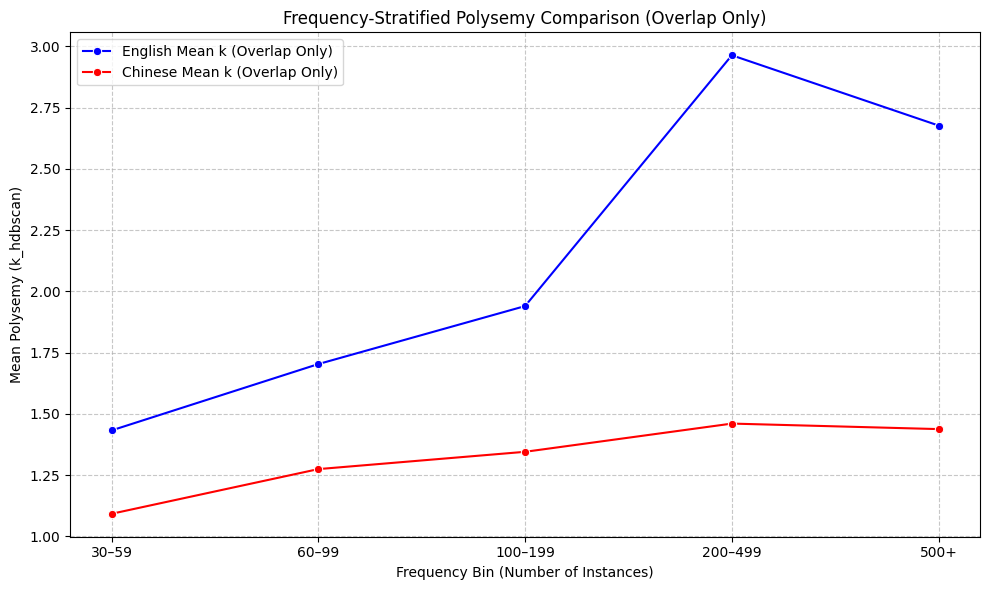

In [12]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu # Needed for bin_df calculation
import numpy as np # Needed for bin_df calculation if not already imported

# Define DATA_DIR and OUTPUT_DIR for this cell
DATA_DIR = Path("/content") / "bible_data"
OUTPUT_DIR = Path("/content") / "output"
FIG_DIR    = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

# Re-calculate bin_df (from previous cells: LXgPj1knDfH, E216lrC8naUB, sQC1rwEhnn-d, LE16SdJXoE-X)
# Load per-instance sense labels
en_labels = pd.read_csv(DATA_DIR / "english_sense_labels.csv")
zh_labels = pd.read_csv(DATA_DIR / "chinese_sense_labels.csv")

# Merge on verse_id to get co-occurring lemmas
merged = en_labels.merge(
    zh_labels,
    on="verse_id",
    suffixes=("_en", "_zh")
)

# Count lemma co-occurrence pairs
pair_counts = (
    merged.groupby(["lemma_en", "lemma_zh"])
    .size()
    .reset_index(name="co_occurrences")
)

# Keep only strong overlaps (at least 10 shared verses)
pair_counts = pair_counts[pair_counts["co_occurrences"] >= 10]

# Lemmas that participate in aligned pairs
en_overlap = set(pair_counts["lemma_en"])
zh_overlap = set(pair_counts["lemma_zh"])

# Load WSI results (assuming 'en' and 'zh' from W2ciQBzRtimn are in scope, but better to load locally)
en_wsi = pd.read_csv(DATA_DIR / "english_wsi_results.csv")
zh_wsi = pd.read_csv(DATA_DIR / "chinese_wsi_results.csv")

# Restrict WSI results to overlap lemmas only
en_overlap_df = en_wsi[en_wsi["lemma"].isin(en_overlap)]
zh_overlap_df = zh_wsi[zh_wsi["lemma"].isin(zh_overlap)]

# Define bins for frequency stratification
bins = [30, 60, 100, 200, 500, 1000]
labels = ["30–59", "60–99", "100–199", "200–499", "500+"]

def assign_bin(n):
    for i in range(len(bins)-1):
        if bins[i] <= n < bins[i+1]:
            return labels[i]
    if n >= bins[-1]:
        return labels[-1]
    return None

# Assign bins to overlap dataframes
en_overlap_df = en_overlap_df.copy() # Avoid SettingWithCopyWarning
zh_overlap_df = zh_overlap_df.copy() # Avoid SettingWithCopyWarning

en_overlap_df["freq_bin"] = en_overlap_df["n_instances"].apply(assign_bin)
zh_overlap_df["freq_bin"] = zh_overlap_df["n_instances"].apply(assign_bin)

# Remove words outside bins
en_bin_overlap_df = en_overlap_df.dropna(subset=["freq_bin"])
zh_bin_overlap_df = zh_overlap_df.dropna(subset=["freq_bin"])

bin_results = []

for bin_label in labels:
    en_subset = en_bin_overlap_df[
        en_bin_overlap_df["freq_bin"] == bin_label
    ]["k_hdbscan"]

    zh_subset = zh_bin_overlap_df[
        zh_bin_overlap_df["freq_bin"] == bin_label
    ]["k_hdbscan"]

    if len(en_subset) < 5 or len(zh_subset) < 5:
        continue

    # mannwhitneyu imported above
    U, p = mannwhitneyu(en_subset, zh_subset, alternative="two-sided")

    bin_results.append({
        "freq_bin": bin_label,
        "en_mean_k": en_subset.mean(),
        "zh_mean_k": zh_subset.mean(),
        "n_en": len(en_subset),
        "n_zh": len(zh_subset),
        "p_value": p
    })

bin_df = pd.DataFrame(bin_results)

# Now the plotting code
plt.figure(figsize=(10, 6))
sns.lineplot(
    x='freq_bin',
    y='en_mean_k',
    data=bin_df,
    marker='o',
    label='English Mean k (Overlap Only)',
    color='blue'
)
sns.lineplot(
    x='freq_bin',
    y='zh_mean_k',
    data=bin_df,
    marker='o',
    label='Chinese Mean k (Overlap Only)',
    color='red'
)

plt.title('Frequency-Stratified Polysemy Comparison (Overlap Only)')
plt.xlabel('Frequency Bin (Number of Instances)')
plt.ylabel('Mean Polysemy (k_hdbscan)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

## 5.3 Bootstrap Stability

### 5.3.3 Run for both languages

In [14]:
import numpy as np
import pandas as pd
from collections import Counter
import hdbscan
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize

# Re-define DATA_DIR to ensure it's available in this cell
from pathlib import Path
DATA_DIR = Path("/content") / "bible_data"

# --- HDBSCAN constants and function definition (from MqXauqA6EB77) ---
RANDOM_STATE  = 42
LARGE_SAMPLE_SIZE = 200
COMPONENTS_UPPPER_LIMIT = 100
MIN_CLUSTER_DATA_SIZE = 6
MIN_CLUSTER_DATA_PROPORTION = 0.03
SECOND_CLUSTER_THRESHOLD = 0.08

def induce_senses_hdbscan(embeddings: np.ndarray):
    n_samples, n_features = embeddings.shape

    if n_samples < 20:
        return 1, np.zeros(n_samples, dtype=int)

    # L2 normalize
    embeddings = normalize(embeddings)

    # Optional PCA only if large sample size
    if n_samples > LARGE_SAMPLE_SIZE:
        n_components = min(COMPONENTS_UPPPER_LIMIT,
                           n_samples - 1,
                           n_features)
        embeddings = PCA(
            n_components=n_components,
            random_state=RANDOM_STATE
        ).fit_transform(embeddings)
        embeddings = normalize(embeddings)

    min_cluster_size = max(MIN_CLUSTER_DATA_SIZE,
                           int(MIN_CLUSTER_DATA_PROPORTION * n_samples))

    clusterer = hdbscan.HDBSCAN(
        metric="euclidean",
        min_cluster_size=min_cluster_size,
        min_samples=max(5, min_cluster_size // 2),
        cluster_selection_method="eom"
    )

    labels = clusterer.fit_predict(embeddings)

    clusters = set(labels)
    clusters.discard(-1)

    k = len(clusters)

    if k <= 1:
        return 1, np.zeros(n_samples, dtype=int)

    sizes = sorted([sum(labels == c) for c in clusters], reverse=True)

    if sizes[1] / n_samples < SECOND_CLUSTER_THRESHOLD:
        return 1, np.zeros(n_samples, dtype=int)

    return k, labels
# --- End of HDBSCAN function ---


# Definition of bootstrap_k function (from O2S2zyAUqaHc)
def bootstrap_k(embeddings, n_runs=20, sample_ratio=0.8):
    """
    Bootstrap stability for a single lemma.

    Returns:
        mode_k     : most frequent induced k across runs
        stability  : proportion of runs equal to mode_k
        all_ks     : list of k from each run
    """
    n = len(embeddings)

    if n < 20:
        return 1, 1.0, [1]

    ks = []

    for _ in range(n_runs):
        sample_size = int(sample_ratio * n)
        idx = np.random.choice(n, sample_size, replace=False)
        subset = embeddings[idx]

        k, _ = induce_senses_hdbscan(subset)
        ks.append(k)

    counter = Counter(ks)
    mode_k = counter.most_common(1)[0][0]
    stability = counter[mode_k] / n_runs

    return mode_k, stability, ks


# Definition of run_bootstrap_for_language function (from bowr4jXmqwiS)
def run_bootstrap_for_language(lang: str, n_runs=20):
    print(f"\n[{lang.upper()}] Running bootstrap stability...")

    embeddings_file = DATA_DIR / f"{lang}_embeddings.npz"
    results_file = DATA_DIR / f"{lang}_wsi_results.csv"

    data = np.load(embeddings_file, allow_pickle=True)
    lemmas_array = data["lemmas"]
    embeddings = data["embeddings"]

    df = pd.read_csv(results_file)

    stability_records = []

    unique_lemmas = df["lemma"].values

    for i, lemma in enumerate(unique_lemmas):
        mask = (lemmas_array == lemma)
        lemma_embeds = embeddings[mask]

        mode_k, stability, ks = bootstrap_k(
            lemma_embeds,
            n_runs=n_runs,
            sample_ratio=0.8
        )

        stability_records.append({
            "lemma": lemma,
            "n_instances": len(lemma_embeds),
            "k_bootstrap_mode": mode_k,
            "stability": stability
        })

        if (i + 1) % 50 == 0 or (i + 1) == len(unique_lemmas):
            print(f"  {i+1}/{len(unique_lemmas)} lemmas", end="\r")

    stability_df = pd.DataFrame(stability_records)

    out_path = DATA_DIR / f"{lang}_bootstrap_stability.csv"
    stability_df.to_csv(out_path, index=False)

    print(f"\n[{lang.upper()}] Saved bootstrap results \u2192 {out_path.name}")

    return stability_df

en_boot = run_bootstrap_for_language("english", n_runs=20)
zh_boot = run_bootstrap_for_language("chinese", n_runs=20)


[ENGLISH] Running bootstrap stability...
  606/606 lemmas
[ENGLISH] Saved bootstrap results → english_bootstrap_stability.csv

[CHINESE] Running bootstrap stability...
  496/496 lemmas
[CHINESE] Saved bootstrap results → chinese_bootstrap_stability.csv


### 5.3.4 Compare stability across languages

In [15]:
print("\n" + "="*60)
print("Bootstrap Stability Comparison")
print("="*60)

print(f"EN mean stability: {en_boot['stability'].mean():.3f}")
print(f"ZH mean stability: {zh_boot['stability'].mean():.3f}")

from scipy.stats import mannwhitneyu

U, p = mannwhitneyu(
    en_boot["stability"],
    zh_boot["stability"],
    alternative="two-sided"
)

print(f"Stability difference p-value: {p:.6f}")


Bootstrap Stability Comparison
EN mean stability: 0.868
ZH mean stability: 0.943
Stability difference p-value: 0.000000


### 5.3.5 Compare stability for polysemous lemmas only

In [16]:
en_poly = en_boot[en_boot["k_bootstrap_mode"] > 1]
zh_poly = zh_boot[zh_boot["k_bootstrap_mode"] > 1]

print("\nPolysemous-only stability:")
print(f"EN mean stability: {en_poly['stability'].mean():.3f}")
print(f"ZH mean stability: {zh_poly['stability'].mean():.3f}")

U_poly, p_poly = mannwhitneyu(
    en_poly["stability"],
    zh_poly["stability"],
    alternative="two-sided"
)

print(f"Polysemous stability p-value: {p_poly:.6f}")


Polysemous-only stability:
EN mean stability: 0.826
ZH mean stability: 0.817
Polysemous stability p-value: 0.500577


## 5.4 Regression Model

### 5.4.1 Merge and Prepare Data

In [17]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from pathlib import Path

# Ensure 'en' and 'zh' DataFrames are available.
DATA_DIR = Path("/content") / "bible_data"
en = pd.read_csv(DATA_DIR / "english_wsi_results.csv")
zh = pd.read_csv(DATA_DIR / "chinese_wsi_results.csv")

# Add language label
en["language"] = 1   # English
zh["language"] = 0   # Chinese

# Combine
df = pd.concat([en, zh], ignore_index=True)

# Log frequency
df["log_freq"] = np.log(df["n_instances"])

# Response variable
df["k"] = df["k_hdbscan"]

### 5.4.2 Poisson Regression

In [18]:
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np
import statsmodels.api as sm
from pathlib import Path

# Ensure 'en' and 'zh' DataFrames are available.
DATA_DIR = Path("/content") / "bible_data"
en = pd.read_csv(DATA_DIR / "english_wsi_results.csv")
zh = pd.read_csv(DATA_DIR / "chinese_wsi_results.csv")

# Add language label
en["language"] = 1   # English
zh["language"] = 0   # Chinese

# Combine
df = pd.concat([en, zh], ignore_index=True)

# Log frequency
df["log_freq"] = np.log(df["n_instances"])

# Response variable
df["k"] = df["k_hdbscan"]

poisson_model = smf.glm(
    formula="k ~ language + log_freq",
    data=df,
    family=sm.families.Poisson()
).fit()

print(poisson_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      k   No. Observations:                 1102
Model:                            GLM   Df Residuals:                     1099
Model Family:                 Poisson   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1440.6
Date:                Wed, 29 Jul 2026   Deviance:                       342.91
Time:                        13:31:04   Pearson chi2:                     400.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.1155
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.6722      0.115     -5.832      0.0

### 5.4.3 Check for Overdispersion

In [19]:
mean_k = df["k"].mean()
var_k = df["k"].var()

print("Mean k:", mean_k)
print("Variance k:", var_k)

Mean k: 1.5816696914700545
Variance k: 0.8938689625501122


### 5.4.4 Negative Binomial Regression

In [20]:
nb_model = smf.glm(
    formula="k ~ language + log_freq",
    data=df,
    family=sm.families.NegativeBinomial()
).fit()

print(nb_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      k   No. Observations:                 1102
Model:                            GLM   Df Residuals:                     1099
Model Family:        NegativeBinomial   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1873.6
Date:                Wed, 29 Jul 2026   Deviance:                       114.75
Time:                        13:31:11   Pearson chi2:                     141.
No. Iterations:                     5   Pseudo R-squ. (CS):            0.04539
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.7043      0.196     -3.592      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


### 5.4.5 Interpret Language Coefficient

In [21]:
beta_lang = nb_model.params["language"]
p_lang = nb_model.pvalues["language"]

print("Language coefficient:", beta_lang)
print("p-value:", p_lang)

# Incidence Rate Ratio
irr = np.exp(beta_lang)
print("Incidence Rate Ratio (English vs Chinese):", irr)

Language coefficient: 0.3634762715721055
p-value: 4.519541674206346e-06
Incidence Rate Ratio (English vs Chinese): 1.4383207274106795


### 5.4.6 Visualization

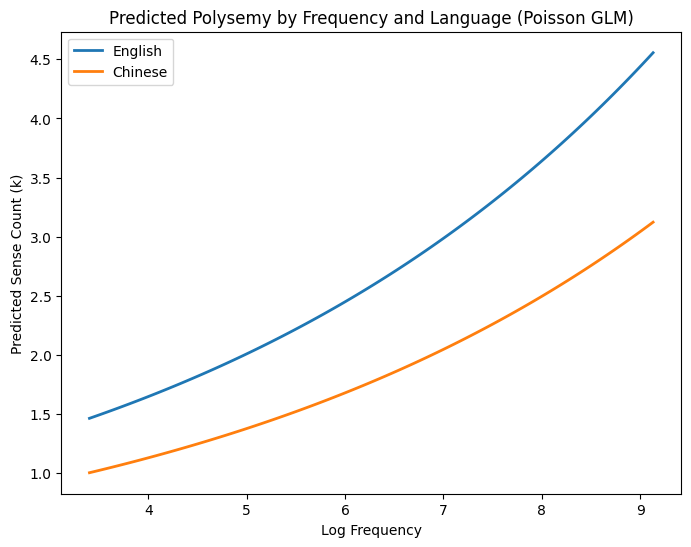

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Create frequency range
freq_range = np.linspace(df["log_freq"].min(), df["log_freq"].max(), 100)

# Create prediction dataframe
pred_df_en = pd.DataFrame({
    "language": 1,
    "log_freq": freq_range
})

pred_df_zh = pd.DataFrame({
    "language": 0,
    "log_freq": freq_range
})

# Predict expected k
pred_en = poisson_model.predict(pred_df_en)
pred_zh = poisson_model.predict(pred_df_zh)

# Plot
plt.figure(figsize=(8,6))
plt.plot(freq_range, pred_en, label="English", linewidth=2)
plt.plot(freq_range, pred_zh, label="Chinese", linewidth=2)
plt.xlabel("Log Frequency")
plt.ylabel("Predicted Sense Count (k)")
plt.title("Predicted Polysemy by Frequency and Language (Poisson GLM)")
plt.legend()
plt.show()

In [23]:
import pandas as pd
from pathlib import Path

# Assuming DATA_DIR, en, zh, en_labels, zh_labels are already defined from previous cells.
# Re-initializing DATA_DIR and loading verse files to make this cell self-contained if run out of order.
DATA_DIR = Path("/content") / "bible_data"

# Load verse content (ensure these are loaded for both languages)
en_verses = pd.read_csv(DATA_DIR / "english_verses.csv")
zh_verses = pd.read_csv(DATA_DIR / "chinese_verses.csv")

def get_polysemy_output(lemma_name, language='english', num_verses_to_show=3):
    if language == 'english':
        wsi_df = en # en dataframe loaded from english_wsi_results.csv
        labels_df = en_labels # en_labels dataframe loaded from english_sense_labels.csv
        verse_content_df = en_verses # English verse content
    elif language == 'chinese':
        wsi_df = zh # zh dataframe loaded from chinese_wsi_results.csv
        labels_df = zh_labels # zh_labels dataframe loaded from chinese_sense_labels.csv
        verse_content_df = zh_verses # Chinese verse content
    else:
        print("Invalid language specified. Please choose 'english' or 'chinese'.")
        return

    # Get k and n for the lemma
    lemma_data = wsi_df[wsi_df['lemma'] == lemma_name]

    if lemma_data.empty:
        print(f"Lemma '{lemma_name}' not found in the {language} WSI results.")
        return

    k = lemma_data['k_hdbscan'].iloc[0]
    n = lemma_data['n_instances'].iloc[0]

    print(f"Lemma: '{lemma_name}'  |  k={k}  |  n={n}")
    print("--------------------------------------------------")

    # Get all instances for the lemma
    lemma_instances = labels_df[labels_df['lemma'] == lemma_name]

    # Group by cluster_hdbscan to find senses and their occurrences
    sense_counts = lemma_instances.groupby('cluster_hdbscan').size().sort_values(ascending=False)

    # Filter out noise cluster (-1) unless it's the only cluster
    senses_to_display = sense_counts[sense_counts.index != -1] if -1 in sense_counts.index and len(sense_counts) > 1 else sense_counts

    if senses_to_display.empty:
        print("  No distinct senses identified (or all instances are noise).")
        return

    for i, (cluster_id, count) in enumerate(senses_to_display.items()):
        sense_label = f"Sense {i + 1}"
        if cluster_id == -1:
            sense_label = "Noise Cluster (-1)"

        print(f"  {sense_label} ({count} occurrences):")

        # Get verse_ids for this sense
        sense_verse_ids = lemma_instances[
            lemma_instances['cluster_hdbscan'] == cluster_id
        ]['verse_id'].drop_duplicates().tolist()

        # Retrieve actual verse texts
        verses_for_sense = verse_content_df[verse_content_df['verse_id'].isin(sense_verse_ids)]

        # Display a sample of verses
        if not verses_for_sense.empty:
            for _, row in verses_for_sense.head(num_verses_to_show).iterrows():
                print(f"    • {row['verse_id']}: {row['text']}") # Corrected column name to 'text'
            if len(verses_for_sense) > num_verses_to_show:
                print(f"    ... (and {len(verses_for_sense) - num_verses_to_show} more verses)")
        else:
            print("    No verses found for this sense.")

# Example usage for 'servant' in English:
get_polysemy_output('servant', language='english')

# Example for another word, e.g., 'time':
# get_polysemy_output('time', language='english')

# Example for a Chinese word (replace with a known lemma from zh_wsi):
# get_polysemy_output('人', language='chinese') # '人' means 'person' or 'people' in Chinese

Lemma: 'servant'  |  k=2  |  n=959
--------------------------------------------------
  Sense 1 (465 occurrences):
    • Gen.9.25: And he said, Cursed be Canaan; a servant of servants shall he be unto his brethren.
    • Gen.14.14: And when Abram heard that his brother was taken captive, he armed his trained servants, born in his own house, three hundred and eighteen, and pursued them unto Dan.
    • Gen.14.15: And he divided himself against them, he and his servants, by night, and smote them, and pursued them unto Hobah, which is on the left hand of Damascus.
    ... (and 424 more verses)
  Sense 2 (459 occurrences):
    • Gen.9.25: And he said, Cursed be Canaan; a servant of servants shall he be unto his brethren.
    • Gen.9.26: And he said, Blessed be the LORD God of Shem; and Canaan shall be his servant.
    • Gen.9.27: God shall enlarge Japheth, and he shall dwell in the tents of Shem; and Canaan shall be his servant.
    ... (and 421 more verses)


In [24]:
# Load per-instance sense labels (if not already loaded)
# en_labels = pd.read_csv(DATA_DIR / "english_sense_labels.csv")

lemma_to_check = 'servant'
verse_to_check = 'Rev.1.1'

# Filter en_labels for the specific lemma and verse
rev_1_1_cluster = en_labels[
    (en_labels['lemma'] == lemma_to_check) &
    (en_labels['verse_id'] == verse_to_check)
]

if not rev_1_1_cluster.empty:
    cluster_id = rev_1_1_cluster['cluster_hdbscan'].iloc[0]
    print(f"The verse '{verse_to_check}' for lemma '{lemma_to_check}' belongs to cluster: {cluster_id}")
    if cluster_id == -1:
        print("This means it was classified as a noise point (not assigned to any clear cluster).")
    elif cluster_id == 0:
        print("This corresponds to Sense 1 (Personal/Domestic Attendant).")
    elif cluster_id == 1:
        print("This corresponds to Sense 2 (Member of a Retinue/Group of Subordinates).")
    else:
        print(f"This is an unhandled cluster ID: {cluster_id}")
else:
    print(f"The verse '{verse_to_check}' for lemma '{lemma_to_check}' was not found in the clustering results. It might not have met the frequency criteria for inclusion or was filtered out.")


The verse 'Rev.1.1' for lemma 'servant' belongs to cluster: 1
This corresponds to Sense 2 (Member of a Retinue/Group of Subordinates).


In [25]:
get_polysemy_output('servant', language='english', num_verses_to_show=5)

Lemma: 'servant'  |  k=2  |  n=959
--------------------------------------------------
  Sense 1 (465 occurrences):
    • Gen.9.25: And he said, Cursed be Canaan; a servant of servants shall he be unto his brethren.
    • Gen.14.14: And when Abram heard that his brother was taken captive, he armed his trained servants, born in his own house, three hundred and eighteen, and pursued them unto Dan.
    • Gen.14.15: And he divided himself against them, he and his servants, by night, and smote them, and pursued them unto Hobah, which is on the left hand of Damascus.
    • Gen.20.8: Therefore Abimelech rose early in the morning, and called all his servants, and told all these things in their ears: and the men were sore afraid.
    • Gen.21.25: And Abraham reproved Abimelech because of a well of water, which Abimelech’s servants had violently taken away.
    ... (and 422 more verses)
  Sense 2 (459 occurrences):
    • Gen.9.25: And he said, Cursed be Canaan; a servant of servants shall he be u

Lemma: 'servant'
Induced senses (k): 2
Number of instances: 959
Cluster labels (first 10): [0 1 0 0 1 1 0 0 0 0]


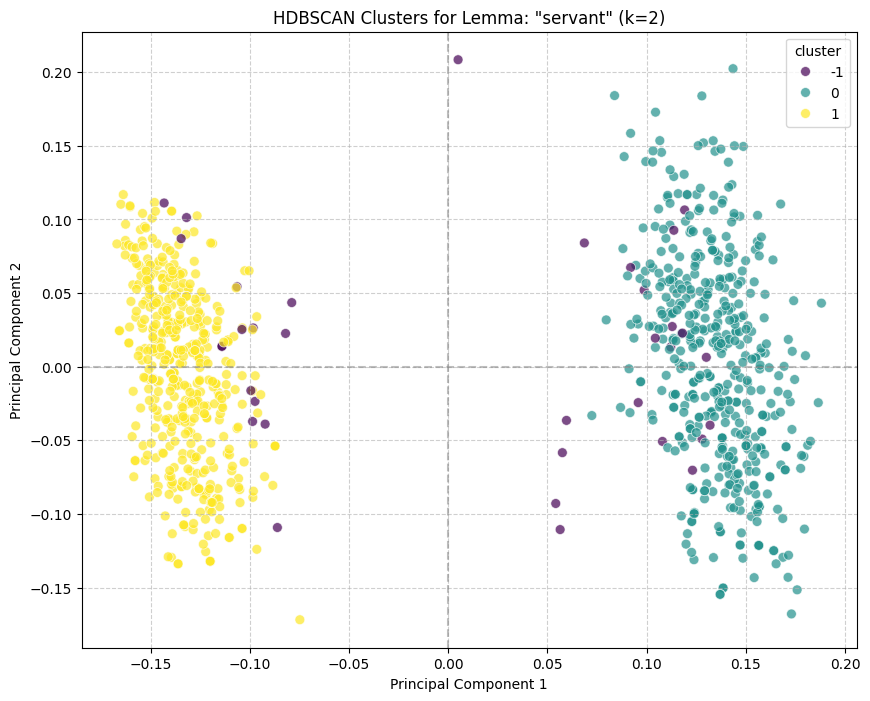

In [26]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import hdbscan
from sklearn.preprocessing import normalize

# Ensure DATA_DIR is defined
DATA_DIR = Path("/content") / "bible_data"

# --- HDBSCAN constants and function definition (copied from MqXauqA6EB77) ---
RANDOM_STATE  = 42
LARGE_SAMPLE_SIZE = 200
COMPONENTS_UPPPER_LIMIT = 100
MIN_CLUSTER_DATA_SIZE = 6
MIN_CLUSTER_DATA_PROPORTION = 0.03
SECOND_CLUSTER_THRESHOLD = 0.08

def induce_senses_hdbscan(embeddings: np.ndarray):
    n_samples, n_features = embeddings.shape

    if n_samples < 20:
        return 1, np.zeros(n_samples, dtype=int)

    # L2 normalize
    embeddings = normalize(embeddings)

    # Optional PCA only if large sample size
    if n_samples > LARGE_SAMPLE_SIZE:
        n_components = min(COMPONENTS_UPPPER_LIMIT,
                           n_samples - 1,
                           n_features)
        embeddings = PCA(
            n_components=n_components,
            random_state=RANDOM_STATE
        ).fit_transform(embeddings)
        embeddings = normalize(embeddings)

    min_cluster_size = max(MIN_CLUSTER_DATA_SIZE,
                           int(MIN_CLUSTER_DATA_PROPORTION * n_samples))

    clusterer = hdbscan.HDBSCAN(
        metric="euclidean",
        min_cluster_size=min_cluster_size,
        min_samples=max(5, min_cluster_size // 2),
        cluster_selection_method="eom"
    )

    labels = clusterer.fit_predict(embeddings)

    clusters = set(labels)
    clusters.discard(-1)

    k = len(clusters)

    if k <= 1:
        return 1, np.zeros(n_samples, dtype=int)

    sizes = sorted([sum(labels == c) for c in clusters], reverse=True)

    if sizes[1] / n_samples < SECOND_CLUSTER_THRESHOLD:
        return 1, np.zeros(n_samples, dtype=int)

    return k, labels
# --- End of HDBSCAN function copy ---

# Load English embeddings and lemmas
en_embeddings_data = np.load(DATA_DIR / "english_embeddings.npz", allow_pickle=True)
en_lemmas_array = en_embeddings_data["lemmas"]
en_embeddings = en_embeddings_data["embeddings"]

lemma_to_plot = 'servant'

# Get embeddings for the specific lemma
mask = (en_lemmas_array == lemma_to_plot)
servant_embeds = en_embeddings[mask]

# Re-run induce_senses_hdbscan for 'servant' to get labels for plotting
k, labels = induce_senses_hdbscan(servant_embeds)

print(f"Lemma: '{lemma_to_plot}'")
print(f"Induced senses (k): {k}")
print(f"Number of instances: {len(servant_embeds)}")
print(f"Cluster labels (first 10): {labels[:10]}")

# Reduce dimensionality for visualization using PCA
# Only reduce if there are enough samples and dimensions
if servant_embeds.shape[0] > 1 and servant_embeds.shape[1] > 1:
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    reduced_embeddings = pca.fit_transform(servant_embeds)
else:
    print("Not enough data points or dimensions for PCA. Skipping plot.")
    reduced_embeddings = None

if reduced_embeddings is not None:
    # Create a DataFrame for plotting
    plot_df = pd.DataFrame(reduced_embeddings, columns=['PC1', 'PC2'])
    plot_df['cluster'] = labels

    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        x='PC1',
        y='PC2',
        hue='cluster',
        palette='viridis' if len(np.unique(labels)) > 1 else ['grey'],
        data=plot_df,
        legend='full' if len(np.unique(labels)) > 1 else False,
        s=50, # size of points
        alpha=0.7
    )
    plt.title(f'HDBSCAN Clusters for Lemma: "{lemma_to_plot}" (k={k})')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.axhline(0, color='grey', linestyle='--', alpha=0.5)
    plt.axvline(0, color='grey', linestyle='--', alpha=0.5)
    plt.show()

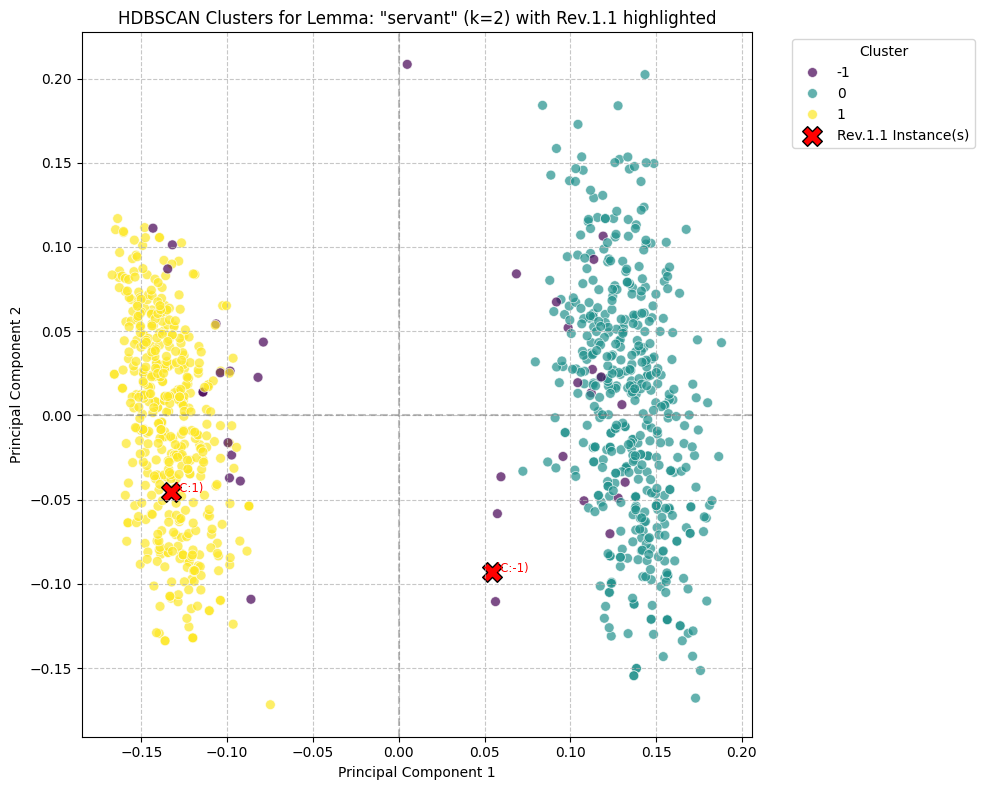

In [27]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import hdbscan
from sklearn.preprocessing import normalize

# Ensure DATA_DIR is defined
DATA_DIR = Path("/content") / "bible_data"

# --- HDBSCAN constants and function definition ---
RANDOM_STATE  = 42
LARGE_SAMPLE_SIZE = 200
COMPONENTS_UPPPER_LIMIT = 100
MIN_CLUSTER_DATA_SIZE = 6
MIN_CLUSTER_DATA_PROPORTION = 0.03
SECOND_CLUSTER_THRESHOLD = 0.08

def induce_senses_hdbscan(embeddings: np.ndarray):
    n_samples, n_features = embeddings.shape

    if n_samples < 20:
        return 1, np.zeros(n_samples, dtype=int)

    # L2 normalize
    embeddings = normalize(embeddings)

    # Optional PCA only if large sample size
    if n_samples > LARGE_SAMPLE_SIZE:
        n_components = min(COMPONENTS_UPPPER_LIMIT,
                           n_samples - 1,
                           n_features)
        embeddings = PCA(
            n_components=n_components,
            random_state=RANDOM_STATE
        ).fit_transform(embeddings)
        embeddings = normalize(embeddings)

    min_cluster_size = max(MIN_CLUSTER_DATA_SIZE,
                           int(MIN_CLUSTER_DATA_PROPORTION * n_samples))

    clusterer = hdbscan.HDBSCAN(
        metric="euclidean",
        min_cluster_size=min_cluster_size,
        min_samples=max(5, min_cluster_size // 2),
        cluster_selection_method="eom"
    )

    labels = clusterer.fit_predict(embeddings)

    clusters = set(labels)
    clusters.discard(-1)

    k = len(clusters)

    if k <= 1:
        return 1, np.zeros(n_samples, dtype=int)

    sizes = sorted([sum(labels == c) for c in clusters], reverse=True)

    if sizes[1] / n_samples < SECOND_CLUSTER_THRESHOLD:
        return 1, np.zeros(n_samples, dtype=int)

    return k, labels

# Load English embeddings and lemmas
en_embeddings_data = np.load(DATA_DIR / "english_embeddings.npz", allow_pickle=True)
en_lemmas_array = en_embeddings_data["lemmas"]
en_embeddings = en_embeddings_data["embeddings"]
en_labels = pd.read_csv(DATA_DIR / "english_sense_labels.csv") # Load en_labels here

lemma_to_plot = 'servant'

# Get embeddings for the specific lemma
mask_all_servant = (en_lemmas_array == lemma_to_plot)
servant_embeds = en_embeddings[mask_all_servant]

# Re-run induce_senses_hdbscan for 'servant' to get labels for plotting
k, labels = induce_senses_hdbscan(servant_embeds)

# Reduce dimensionality for visualization using PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
reduced_embeddings = pca.fit_transform(servant_embeds)

# Create a DataFrame for plotting all 'servant' instances
plot_df = pd.DataFrame(reduced_embeddings, columns=['PC1', 'PC2'])
plot_df['cluster'] = labels

# --- Identify Rev.1.1 instances ---
# Filter en_labels for 'servant' instances and store their original row indices
servant_full_labels = en_labels[en_labels['lemma'] == lemma_to_plot].reset_index(drop=True)

# Find the indices within servant_full_labels (and thus within servant_embeds and reduced_embeddings)
# that correspond to 'Rev.1.1'
rev1_1_local_indices = servant_full_labels[
    servant_full_labels['verse_id'] == 'Rev.1.1'
].index.tolist()

# Get the PC coordinates and cluster labels for Rev.1.1 instances
rev1_1_points = plot_df.loc[rev1_1_local_indices]

# Plotting
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='viridis' if len(np.unique(labels)) > 1 else ['grey'],
    data=plot_df,
    legend='full' if len(np.unique(labels)) > 1 else False,
    s=50, # size of points
    alpha=0.7
)

# Overlay Rev.1.1 points
if not rev1_1_points.empty:
    sns.scatterplot(
        x='PC1',
        y='PC2',
        data=rev1_1_points,
        marker='X', # Use a distinct marker
        s=200,      # Make it larger
        color='red', # Use a distinct color
        label='Rev.1.1 Instance(s)',
        edgecolor='black',
        linewidth=1
    )
    # Add text labels for the Rev.1.1 points if there are multiple
    for i, row in rev1_1_points.iterrows():
        plt.text(row['PC1'], row['PC2'], f' (C:{int(row["cluster"])})',
                 horizontalalignment='left', size='small', color='red')


plt.title(f'HDBSCAN Clusters for Lemma: "{lemma_to_plot}" (k={k}) with Rev.1.1 highlighted')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(0, color='grey', linestyle='--', alpha=0.5)
plt.axvline(0, color='grey', linestyle='--', alpha=0.5)
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Plotting 'friend' clusters

Lemma: 'friend'
Induced senses (k): 2
Number of instances: 96


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


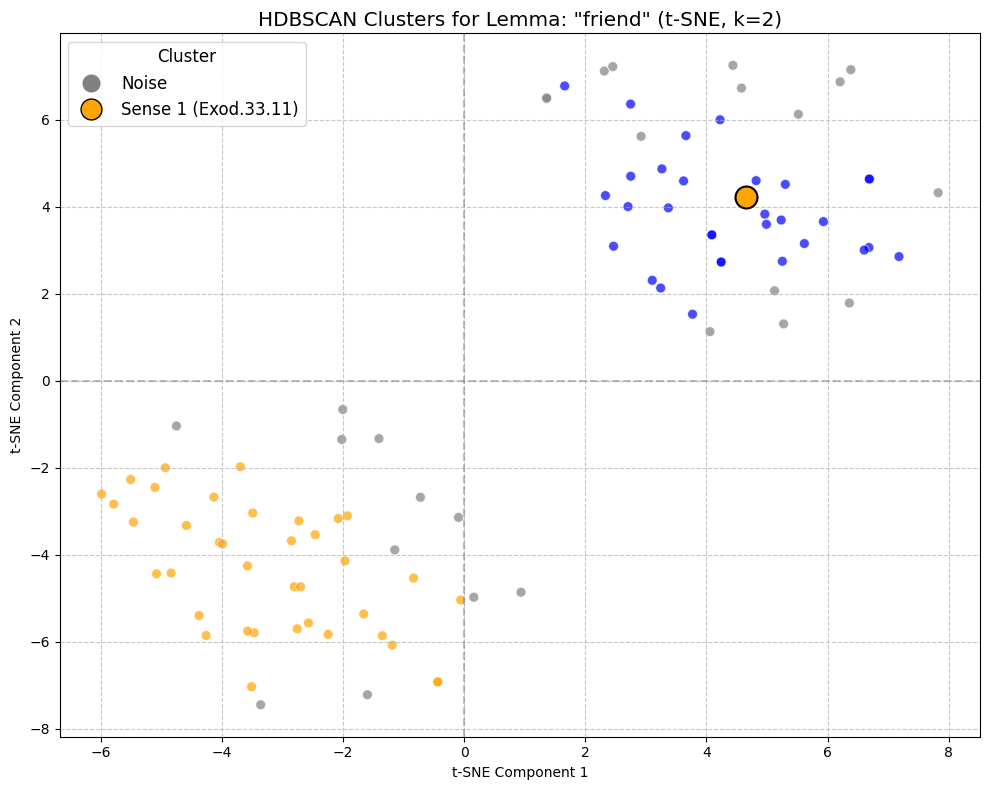

Lemma: 'friend'  |  k=2  |  n=96
--------------------------------------------------
  Sense 1 (38 occurrences):
    • Gen.26.26: Then Abimelech went to him from Gerar, and Ahuzzath one of his friends, and Phichol the chief captain of his army.
    • 1Sam.30.26: And when David came to Ziklag, he sent of the spoil unto the elders of Judah, even to his friends, saying, Behold a present for you of the spoil of the enemies of the LORD;
    • 2Sam.3.8: Then was Abner very wroth for the words of Ishbosheth, and said, Am I a dog’s head, which against Judah do shew kindness this day unto the house of Saul thy father, to his brethren, and to his friends, and have not delivered thee into the hand of David, that thou chargest me to day with a fault concerning this woman?
    ... (and 34 more verses)
  Sense 2 (32 occurrences):
    • Exod.33.11: And the LORD spake unto Moses face to face, as a man speaketh unto his friend. And he turned again into the camp: but his servant Joshua, the son of Nun, a

In [28]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import hdbscan
from sklearn.preprocessing import normalize
from collections import Counter
from matplotlib.lines import Line2D
from sklearn.manifold import TSNE # Import TSNE

# Ensure DATA_DIR is defined
DATA_DIR = Path("/content") / "bible_data"

# --- HDBSCAN constants and function definition (copied for self-containment) ---
RANDOM_STATE  = 42
LARGE_SAMPLE_SIZE = 200
COMPONENTS_UPPPER_LIMIT = 100
MIN_CLUSTER_DATA_SIZE = 6
MIN_CLUSTER_DATA_PROPORTION = 0.03
SECOND_CLUSTER_THRESHOLD = 0.08

def induce_senses_hdbscan(embeddings: np.ndarray):
    n_samples, n_features = embeddings.shape

    if n_samples < 20:
        return 1, np.zeros(n_samples, dtype=int)

    # L2 normalize
    embeddings = normalize(embeddings)

    # Optional PCA only if large sample size
    if n_samples > LARGE_SAMPLE_SIZE:
        n_components = min(COMPONENTS_UPPPER_LIMIT,
                           n_samples - 1,
                           n_features)
        embeddings = PCA(
            n_components=n_components,
            random_state=RANDOM_STATE
        ).fit_transform(embeddings)
        embeddings = normalize(embeddings)

    min_cluster_size = max(MIN_CLUSTER_DATA_SIZE,
                           int(MIN_CLUSTER_DATA_PROPORTION * n_samples))

    clusterer = hdbscan.HDBSCAN(
        metric="euclidean",
        min_cluster_size=min_cluster_size,
        min_samples=max(5, min_cluster_size // 2),
        cluster_selection_method="eom"
    )

    labels = clusterer.fit_predict(embeddings)

    clusters = set(labels)
    clusters.discard(-1)

    k = len(clusters)

    if k <= 1:
        return 1, np.zeros(n_samples, dtype=int)

    sizes = sorted([sum(labels == c) for c in clusters], reverse=True)

    if sizes[1] / n_samples < SECOND_CLUSTER_THRESHOLD:
        return 1, np.zeros(n_samples, dtype=int)

    return k, labels

# --- End of HDBSCAN function copy ---

# --- get_polysemy_output function (copied for self-containment) ---
# Assuming 'en' and 'zh' dataframes are available from previous cells,
# and en_labels, zh_labels, en_verses, zh_verses are loaded.
# To make this cell runnable independently, re-load necessary data.

en = pd.read_csv(DATA_DIR / "english_wsi_results.csv")
zh = pd.read_csv(DATA_DIR / "chinese_wsi_results.csv")
en_labels = pd.read_csv(DATA_DIR / "english_sense_labels.csv")
zh_labels = pd.read_csv(DATA_DIR / "chinese_sense_labels.csv")
en_verses = pd.read_csv(DATA_DIR / "english_verses.csv")
zh_verses = pd.read_csv(DATA_DIR / "chinese_verses.csv")

def get_polysemy_output(lemma_name, language='english', num_verses_to_show=3):
    if language == 'english':
        wsi_df = en # en dataframe loaded from english_wsi_results.csv
        labels_df = en_labels # en_labels dataframe loaded from english_sense_labels.csv
        verse_content_df = en_verses # English verse content
    elif language == 'chinese':
        wsi_df = zh # zh dataframe loaded from chinese_wsi_results.csv
        labels_df = zh_labels # zh_labels dataframe loaded from chinese_sense_labels.csv
        verse_content_df = zh_verses # Chinese verse content
    else:
        print("Invalid language specified. Please choose 'english' or 'chinese'.")
        return

    # Get k and n for the lemma
    lemma_data = wsi_df[wsi_df['lemma'] == lemma_name]

    if lemma_data.empty:
        print(f"Lemma '{lemma_name}' not found in the {language} WSI results.")
        return

    k = lemma_data['k_hdbscan'].iloc[0]
    n = lemma_data['n_instances'].iloc[0]

    print(f"Lemma: '{lemma_name}'  |  k={k}  |  n={n}")
    print("--------------------------------------------------")

    # Get all instances for the lemma
    lemma_instances = labels_df[
        labels_df['lemma'] == lemma_name
    ]

    # Group by cluster_hdbscan to find senses and their occurrences
    sense_counts = lemma_instances.groupby('cluster_hdbscan').size().sort_values(ascending=False)

    # Filter out noise cluster (-1) unless it's the only cluster
    senses_to_display = sense_counts[sense_counts.index != -1] if -1 in sense_counts.index and len(sense_counts) > 1 else sense_counts

    if senses_to_display.empty:
        print("  No distinct senses identified (or all instances are noise).")
        return

    for i, (cluster_id, count) in enumerate(senses_to_display.items()):
        sense_label = f"Sense {i + 1}"
        if cluster_id == -1:
            sense_label = "Noise Cluster (-1)"

        print(f"  {sense_label} ({count} occurrences):")

        # Get verse_ids for this sense
        sense_verse_ids = lemma_instances[
            lemma_instances['cluster_hdbscan'] == cluster_id
        ]['verse_id'].drop_duplicates().tolist()

        # Retrieve actual verse texts
        verses_for_sense = verse_content_df[verse_content_df['verse_id'].isin(sense_verse_ids)]

        # Display a sample of verses
        if not verses_for_sense.empty:
            for _, row in verses_for_sense.head(num_verses_to_show).iterrows():
                print(f"    • {row['verse_id']}: {row['text']}") # Corrected column name to 'text'
            if len(verses_for_sense) > num_verses_to_show:
                print(f"    ... (and {len(verses_for_sense) - num_verses_to_show} more verses)")
        else:
            print("    No verses found for this sense.")
# --- End of get_polysemy_output function copy ---


# Load English embeddings and lemmas
en_embeddings_data = np.load(DATA_DIR / "english_embeddings.npz", allow_pickle=True)
en_lemmas_array = en_embeddings_data["lemmas"]
en_embeddings = en_embeddings_data["embeddings"]

lemma_to_plot = 'friend'

# Get embeddings for the specific lemma
mask_all_lemma = (en_lemmas_array == lemma_to_plot)
lemma_embeds = en_embeddings[mask_all_lemma]

# Re-run induce_senses_hdbscan for 'friend' to get labels for plotting
k_friend, labels_friend = induce_senses_hdbscan(lemma_embeds)

print(f"Lemma: '{lemma_to_plot}'")
print(f"Induced senses (k): {k_friend}")
print(f"Number of instances: {len(lemma_embeds)}")

# Reduce dimensionality for visualization using t-SNE
if lemma_embeds.shape[0] > 1 and lemma_embeds.shape[1] > 1:
    tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, n_iter=1000, learning_rate='auto')
    reduced_embeddings_friend = tsne.fit_transform(lemma_embeds)
else:
    print("Not enough data points or dimensions for t-SNE. Skipping plot.")
    reduced_embeddings_friend = None

if reduced_embeddings_friend is not None:
    # Create a DataFrame for plotting
    plot_df_friend = pd.DataFrame(reduced_embeddings_friend, columns=['Component 1', 'Component 2'])
    plot_df_friend['cluster'] = labels_friend

    # Determine unique clusters in the data for consistent color mapping
    unique_clusters_in_data = sorted(plot_df_friend['cluster'].unique())

    # Define custom colors for non-noise clusters
    custom_colors = ['orange', 'blue', 'green', 'red', 'purple', 'brown'] # Add more if needed

    cluster_color_map = {}
    non_noise_idx = 0
    for cluster_id in unique_clusters_in_data:
        if cluster_id == -1:
            cluster_color_map[cluster_id] = 'grey' # Assign grey to noise
        else:
            # Assign custom colors cyclically
            cluster_color_map[cluster_id] = custom_colors[non_noise_idx % len(custom_colors)]
            non_noise_idx += 1

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.scatterplot(
        x='Component 1',
        y='Component 2',
        hue='cluster',
        palette=cluster_color_map, # Use the defined color map
        data=plot_df_friend,
        legend=False, # Disable seaborn's legend to build custom one
        s=50,
        alpha=0.7,
        ax=ax
    )

    # --- Highlight specific verses ---
    # Get all instances for 'friend' from en_labels to find verse indices
    friend_full_labels = en_labels[en_labels['lemma'] == lemma_to_plot].reset_index(drop=True)

    # Define specific verses to highlight and their corresponding cluster ID
    # These cluster IDs are derived from the order of senses in get_polysemy_output
    # (largest cluster first for Sense 1, etc.)
    # Cluster 0 -> Sense 1
    # Cluster 2 -> Sense 2
    # Cluster 1 -> Sense 3
    highlight_verses_with_cluster_id = {
        'Exod.33.11': 0, # Corresponds to Sense 1
        'Judg.11.37': 2, # Corresponds to Sense 2
        'Gen.19.7': 1    # Corresponds to Sense 3
    }

    markers = ['o', 's', '^'] # Different markers for each highlighted verse
    highlight_legend_elements = []

    # Map the cluster_id to the 'Sense X' label for highlight legend entries
    sense_counts_for_friend = Counter(labels_friend)
    sorted_clusters_by_count = sorted([c for c in sense_counts_for_friend if c != -1], key=lambda x: sense_counts_for_friend[x], reverse=True)

    cluster_id_to_sense_rank_label = {}
    for i, cluster_id in enumerate(sorted_clusters_by_count):
        cluster_id_to_sense_rank_label[cluster_id] = f'Sense {i + 1}'

    for i, (verse_id, cluster_id_for_highlight) in enumerate(highlight_verses_with_cluster_id.items()):
        local_indices = friend_full_labels[
            friend_full_labels['verse_id'] == verse_id
        ].index.tolist()

        if local_indices:
            highlight_points = plot_df_friend.loc[local_indices]
            highlight_color = cluster_color_map.get(cluster_id_for_highlight, 'black')

            sns.scatterplot(
                x='Component 1',
                y='Component 2',
                data=highlight_points,
                marker=markers[i],
                s=250,
                color=highlight_color,
                edgecolor='black',
                linewidth=1.5,
                zorder=5,
                ax=ax
            )
            # Create a Line2D object for this highlight point to add to the custom legend
            sense_label_for_highlight = cluster_id_to_sense_rank_label.get(cluster_id_for_highlight, f'Cluster {cluster_id_for_highlight}')
            highlight_legend_elements.append(
                Line2D([0], [0],
                       marker=markers[i],
                       color='w',
                       markerfacecolor=highlight_color,
                       markeredgecolor='black',
                       markersize=10,
                       label=f'{sense_label_for_highlight} ({verse_id})')
            )

    # --- Build custom legend ---
    legend_elements = []

    # Add Noise if present
    if -1 in unique_clusters_in_data:
        legend_elements.append(
            Line2D([0], [0],
                   marker='o',
                   color='w',
                   markerfacecolor=cluster_color_map[-1],
                   markeredgecolor=cluster_color_map[-1],
                   markersize=8,
                   label='Noise')
        )

    # Add highlight verse elements
    legend_elements.extend(highlight_legend_elements)

    ax.legend(handles=legend_elements, title='Cluster', loc='upper left',
              fontsize='large', title_fontsize='large', markerscale=1.5)

    plt.title(f'HDBSCAN Clusters for Lemma: "{lemma_to_plot}" (t-SNE, k={k_friend})', fontsize='x-large')
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.axhline(0, color='grey', linestyle='--', alpha=0.5)
    plt.axvline(0, color='grey', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print(f"Could not generate plot for '{lemma_to_plot}'.")

# Describe the senses for 'friend'
get_polysemy_output('friend', language='english')

if k_friend != 3:
    print(f"\nNote: The HDBSCAN algorithm determined {k_friend} senses for 'friend', not 3 as you mentioned. The `induce_senses_hdbscan` function automatically identifies the optimal number of clusters based on its parameters and the data's inherent structure, rather than allowing for a fixed number of clusters to be enforced.")

### 5.4.7 Plotting Multiple Lemmas Together

Lemma: 'friend' | Induced senses (k): 2 | Number of instances: 96
Lemma: 'brother' | Induced senses (k): 2 | Number of instances: 955
Lemma: 'neighbor' | Induced senses (k): 1 | Number of instances: 0


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


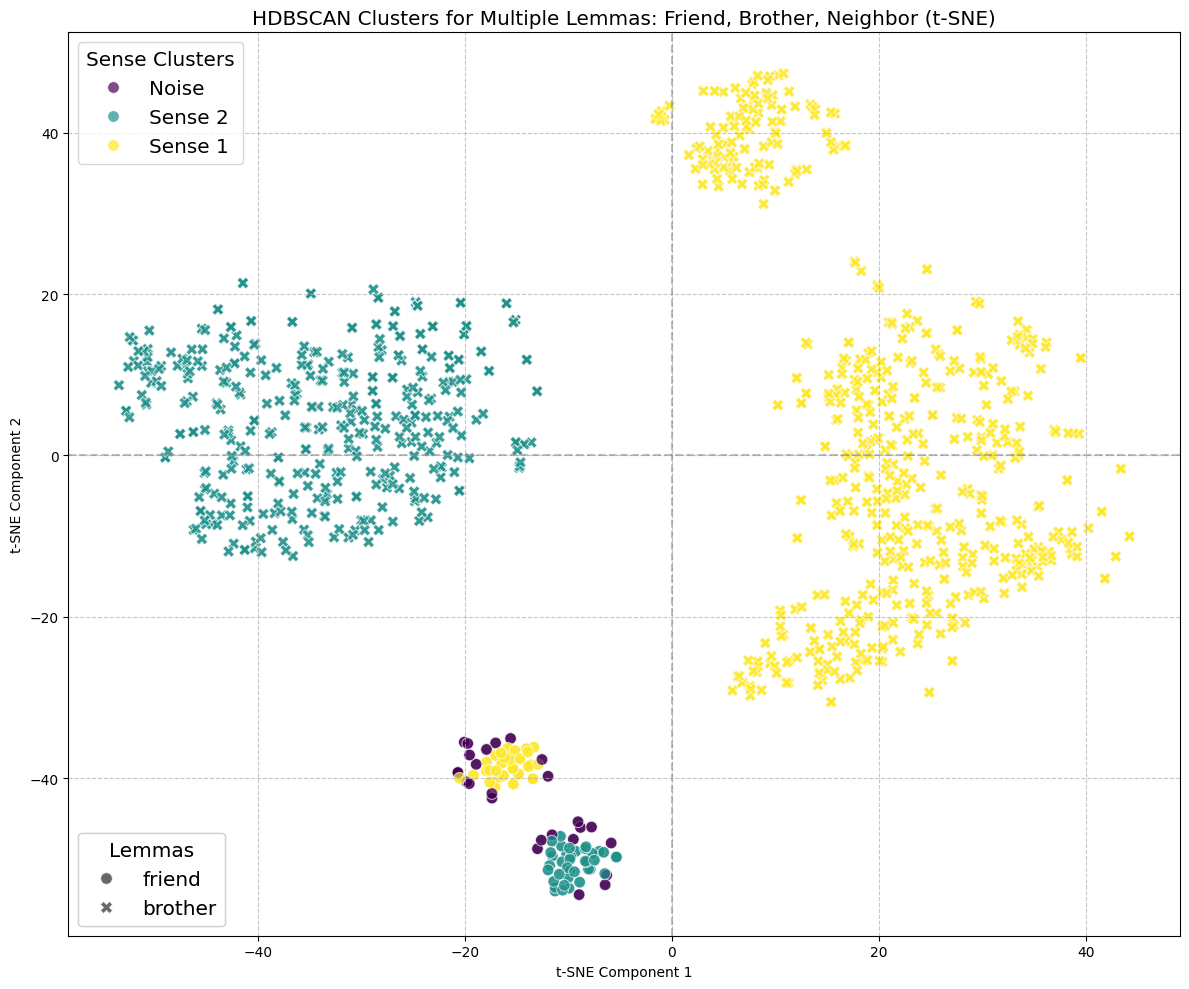

In [29]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import hdbscan
from sklearn.preprocessing import normalize
from collections import Counter
from matplotlib.lines import Line2D
from sklearn.manifold import TSNE # Import TSNE

# Ensure DATA_DIR is defined
DATA_DIR = Path("/content") / "bible_data"

# --- HDBSCAN constants and function definition (copied for self-containment) ---
RANDOM_STATE  = 42
LARGE_SAMPLE_SIZE = 200
COMPONENTS_UPPPER_LIMIT = 100
MIN_CLUSTER_DATA_SIZE = 6
MIN_CLUSTER_DATA_PROPORTION = 0.03
SECOND_CLUSTER_THRESHOLD = 0.08

def induce_senses_hdbscan(embeddings: np.ndarray):
    n_samples, n_features = embeddings.shape

    if n_samples < 20:
        return 1, np.zeros(n_samples, dtype=int)

    # L2 normalize
    embeddings = normalize(embeddings)

    # Optional PCA only if large sample size
    if n_samples > LARGE_SAMPLE_SIZE:
        n_components = min(COMPONENTS_UPPPER_LIMIT,
                           n_samples - 1,
                           n_features)
        embeddings = PCA(
            n_components=n_components,
            random_state=RANDOM_STATE
        ).fit_transform(embeddings)
        embeddings = normalize(embeddings)

    min_cluster_size = max(MIN_CLUSTER_DATA_SIZE,
                           int(MIN_CLUSTER_DATA_PROPORTION * n_samples))

    clusterer = hdbscan.HDBSCAN(
        metric="euclidean",
        min_cluster_size=min_cluster_size,
        min_samples=max(5, min_cluster_size // 2),
        cluster_selection_method="eom"
    )

    labels = clusterer.fit_predict(embeddings)

    clusters = set(labels)
    clusters.discard(-1)

    k = len(clusters)

    if k <= 1:
        return 1, np.zeros(n_samples, dtype=int)

    sizes = sorted([sum(labels == c) for c in clusters], reverse=True)

    if sizes[1] / n_samples < SECOND_CLUSTER_THRESHOLD:
        return 1, np.zeros(n_samples, dtype=int)

    return k, labels
# --- End of HDBSCAN function copy ---


# List of lemmas to plot
lemmas_to_plot = ['friend', 'brother', 'neighbor']

# Load English embeddings data
en_embeddings_data = np.load(DATA_DIR / "english_embeddings.npz", allow_pickle=True)
en_lemmas_array = en_embeddings_data["lemmas"]
en_embeddings = en_embeddings_data["embeddings"]

all_embeddings_for_pca = []
all_lemma_labels = []
all_cluster_labels = []

# Store results for plotting
plotting_data = []

for lemma_name in lemmas_to_plot:
    mask = (en_lemmas_array == lemma_name)
    lemma_embeds = en_embeddings[mask]

    # Induce senses
    k, labels = induce_senses_hdbscan(lemma_embeds)

    # Store embeddings and labels
    all_embeddings_for_pca.append(lemma_embeds)
    all_lemma_labels.extend([lemma_name] * len(lemma_embeds))
    all_cluster_labels.extend(labels)

    print(f"Lemma: '{lemma_name}' | Induced senses (k): {k} | Number of instances: {len(lemma_embeds)}")

# Concatenate all embeddings for a unified space
combined_embeddings = np.vstack(all_embeddings_for_pca)

# Perform t-SNE dimensionality reduction
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, n_iter=1000, learning_rate='auto')
reduced_combined_embeddings = tsne.fit_transform(combined_embeddings)

# Create a unified DataFrame for plotting
final_plot_df = pd.DataFrame(reduced_combined_embeddings, columns=['Component 1', 'Component 2']) # Changed column names
final_plot_df['lemma'] = all_lemma_labels
final_plot_df['cluster'] = all_cluster_labels

# Plotting
fig, ax = plt.subplots(figsize=(12, 10))

# Temporary scatterplot to get default legend handles and labels for style
temp_scatter = sns.scatterplot(
    x='Component 1', y='Component 2',
    hue='cluster', style='lemma', # Keep hue and style
    palette='viridis', data=final_plot_df,
    s=70, alpha=0.7, ax=ax, legend='full' # Generate full legend temporarily
)

# Get all handles and labels from the full legend
full_handles, full_labels = ax.get_legend_handles_labels()
ax.get_legend().remove() # Remove the temporary seaborn legend

# Identify the number of actual unique clusters (excluding the 'cluster' title)
unique_cluster_ids = np.sort(final_plot_df['cluster'].unique())
num_actual_clusters = len(unique_cluster_ids)

# Extract handles and labels for the cluster legend
# The hue title is at index 0, actual hue labels are from index 1 up to (1 + num_actual_clusters - 1)
cluster_handles = full_handles[1 : 1 + num_actual_clusters]
original_cluster_labels = full_labels[1 : 1 + num_actual_clusters]

# The style title is at index 1 + num_actual_clusters, actual style labels are from index 2 + num_actual_clusters onwards
lemma_handles = full_handles[1 + num_actual_clusters + 1 : ]
lemma_labels = full_labels[1 + num_actual_clusters + 1 : ]

# Map cluster IDs to Sense labels, sorting by count for Sense 1, Sense 2, etc.
cluster_counts = final_plot_df.groupby('cluster').size().sort_values(ascending=False)
sense_mapping = {}
sense_counter = 1
for cluster_id, count in cluster_counts.items():
    if cluster_id == -1:
        sense_mapping[-1] = 'Noise'
    else:
        sense_mapping[cluster_id] = f'Sense {sense_counter}'
        sense_counter += 1

# Apply sense mapping to the cluster labels
final_cluster_labels = []
for label_str in original_cluster_labels:
    cluster_id = int(label_str) # This should now work as label_str will be '-1', '0', '1', etc.
    final_cluster_labels.append(sense_mapping.get(cluster_id, f'Cluster {cluster_id}'))

# Re-plot the scatterplot without legend (to avoid duplicates)
sns.scatterplot(
    x='Component 1', y='Component 2',
    hue='cluster', style='lemma',
    palette='viridis', data=final_plot_df,
    s=70, alpha=0.7, ax=ax, legend=False # Now draw without legend
)

plt.title('HDBSCAN Clusters for Multiple Lemmas: Friend, Brother, Neighbor (t-SNE)', fontsize='x-large') # Updated title
plt.xlabel('t-SNE Component 1') # Updated x-axis label
plt.ylabel('t-SNE Component 2') # Updated y-axis label
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(0, color='grey', linestyle='--', alpha=0.5)
plt.axvline(0, color='grey', linestyle='--', alpha=0.5)

# Add the custom cluster legend
cluster_legend = ax.legend(handles=cluster_handles, labels=final_cluster_labels,
                           title='Sense Clusters', loc='upper left',
                           fontsize='x-large', title_fontsize='x-large') # Changed to x-large
ax.add_artist(cluster_legend) # Add this legend to the figure

# Add the lemma legend
lemma_legend = ax.legend(handles=lemma_handles, labels=lemma_labels,
                         title='Lemmas', loc='lower left', # Position differently
                         fontsize='x-large', title_fontsize='x-large') # Changed to x-large
ax.add_artist(lemma_legend) # Add this legend to the figure

plt.tight_layout()
plt.show()

### Plotting Multiple Chinese Lemmas

Checking for Noto Sans CJK font installation...
Installing fonts-noto-cjk package...
fonts-noto-cjk package installed.
Deleted font cache file: /root/.cache/matplotlib/fontlist-v390.json
Matplotlib font cache cleared and rebuilt after installation.
Found font file after installation at: /usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc
Actual font family name registered by matplotlib: 'Noto Sans CJK JP'
Matplotlib font configured to use 'Noto Sans CJK JP'.
Re-imported matplotlib.pyplot to apply font settings.
Lemma: '弟兄' | Induced senses (k): 2 | Number of instances: 695
Lemma: '鄰舍' | Induced senses (k): 1 | Number of instances: 97
Lemma: '同伴' | Induced senses (k): 1 | Number of instances: 34
Lemma: '朋友' | Induced senses (k): 1 | Number of instances: 91


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


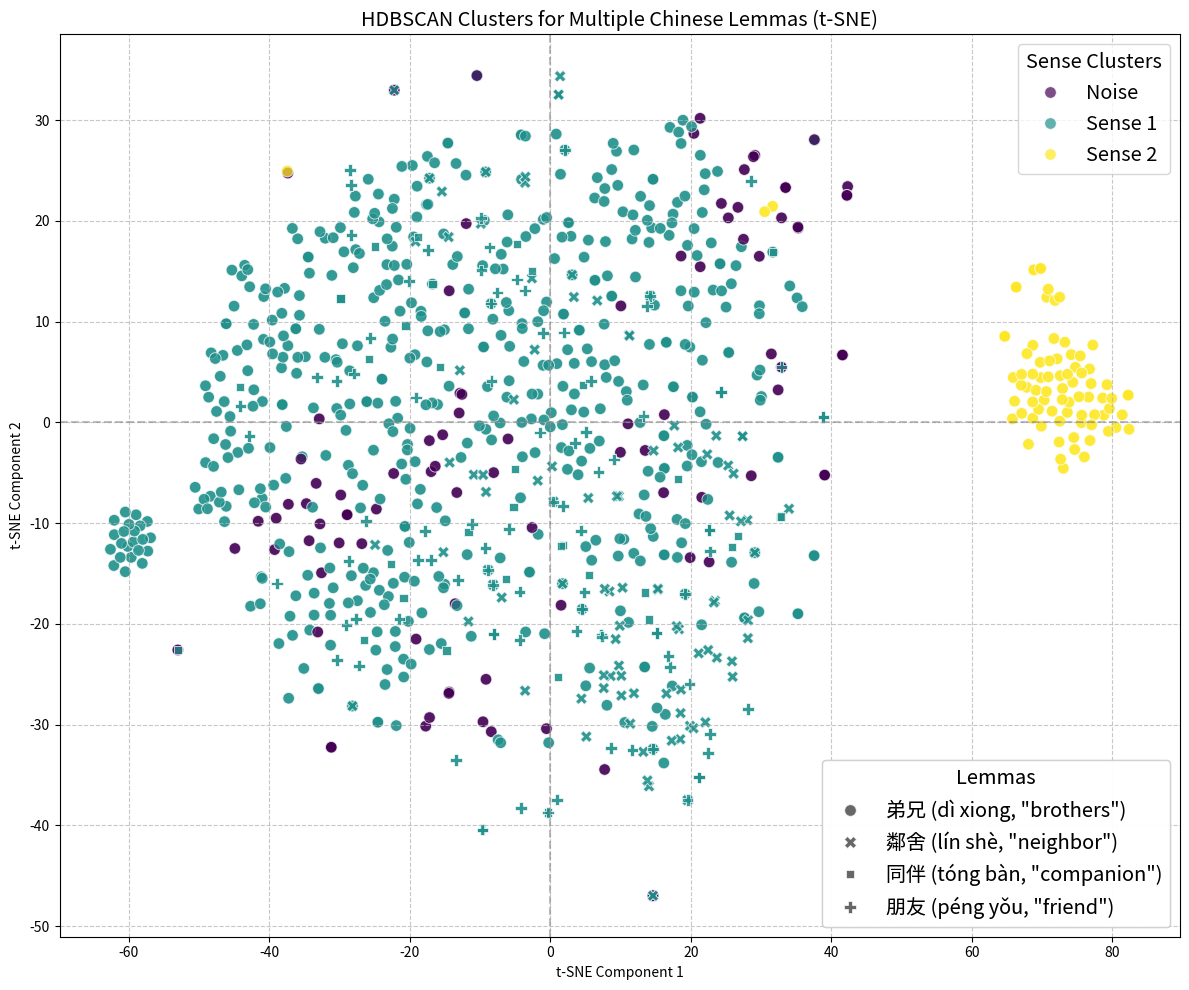

In [30]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt # Initial import
import seaborn as sns
from pathlib import Path
import hdbscan
from sklearn.preprocessing import normalize
from collections import Counter
from matplotlib.lines import Line2D
from sklearn.manifold import TSNE # Import TSNE for t-SNE

# --- Install and configure Chinese fonts for matplotlib ---
try:
    import matplotlib.font_manager as fm
    import os
    import subprocess
    import matplotlib

    font_name_desired_keyword = 'Noto Sans CJK' # Broader keyword for finding
    actual_font_family_name = None
    font_path_found = None

    print(f"Checking for {font_name_desired_keyword} font installation...")

    # Define known font file names and common installation paths
    # These are specific file names that `fonts-noto-cjk` is known to install.
    noto_cjk_filenames = [
        'NotoSansCJK-Regular.ttc', # Common for multiple CJK variants
        'NotoSansCJKjp-Regular.otf',
        'NotoSansCJKkr-Regular.otf',
        'NotoSansCJKsc-Regular.otf',
        'NotoSansCJKtc-Regular.otf',
        'NotoSansCJKjp-Medium.otf', # sometimes medium variant is present
        'NotoSansCJKjp-Bold.otf',
    ]
    common_font_dirs = [
        '/usr/share/fonts/opentype/noto/',
        '/usr/share/fonts/truetype/noto/',
        '/usr/local/share/fonts/',
        '/usr/share/fonts/custom/',
        '/usr/share/fonts/', # General system font path
    ]

    # --- Phase 1: Try to find Noto CJK font without installation first ---
    temp_font_path_found = None
    for font_dir in common_font_dirs:
        for filename in noto_cjk_filenames:
            candidate_path = Path(font_dir) / filename
            if candidate_path.exists():
                temp_font_path_found = str(candidate_path)
                break
        if temp_font_path_found:
            break

    # If a potential Noto CJK font file is found, check its actual family name
    if temp_font_path_found:
        # Clear matplotlib's font cache using the correct method and fallbacks
        cache_dirs_to_check = [Path(matplotlib.get_cachedir())] # Correct way to get cache dir
        # Add common fallback locations for older matplotlib versions or specific setups
        cache_dirs_to_check.extend([Path.home() / '.cache/matplotlib', Path('/tmp/.matplotlib')])

        for cache_dir in cache_dirs_to_check:
            if cache_dir.is_dir():
                for f in cache_dir.glob('fontlist-v*.json'):
                    try:
                        f.unlink()
                        print(f"Deleted font cache file: {f}")
                    except OSError as e:
                        print(f"Error deleting {f}: {e}")
        fm._load_fontmanager(try_read_cache=False)

        fm.fontManager.addfont(temp_font_path_found)
        fm._load_fontmanager(try_read_cache=False) # Reload to pick up newly added font

        prop = fm.FontProperties(fname=temp_font_path_found)
        actual_name = prop.get_name()

        if 'Noto Sans CJK' in actual_name or 'NotoSerifCJK' in actual_name:
            font_path_found = temp_font_path_found
            actual_font_family_name = actual_name
            print(f"Found existing CJK font '{actual_font_family_name}' at: {font_path_found}")
        else:
            print(f"Found a font file at {temp_font_path_found}, but its actual family name '{actual_name}' does not seem to be Noto CJK. Will attempt installation.")
            font_path_found = None # Reset if not actual Noto CJK

    # --- Phase 2: Install if not found, then re-search ---
    if not font_path_found:
        print(f"Installing fonts-noto-cjk package...")
        subprocess.run(['sudo', 'apt-get', 'update'], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL, check=True)
        subprocess.run(['sudo', 'apt-get', 'install', '-y', 'fonts-noto-cjk'], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL, check=True)
        print(f"fonts-noto-cjk package installed.")

        # Clear matplotlib's font cache after installation to force it to re-scan
        cache_dirs_to_check = [Path(matplotlib.get_cachedir())]
        cache_dirs_to_check.extend([Path.home() / '.cache/matplotlib', Path('/tmp/.matplotlib')])

        for cache_dir in cache_dirs_to_check:
            if cache_dir.is_dir():
                for f in cache_dir.glob('fontlist-v*.json'):
                    try:
                        f.unlink()
                        print(f"Deleted font cache file: {f}")
                    except OSError as e:
                        print(f"Error deleting {f}: {e}")
        fm._load_fontmanager(try_read_cache=False)
        print("Matplotlib font cache cleared and rebuilt after installation.")

        # Re-search for the specific Noto CJK font file after installation
        for font_dir in common_font_dirs:
            for filename in noto_cjk_filenames:
                candidate_path = Path(font_dir) / filename
                if candidate_path.exists():
                    font_path_found = str(candidate_path)
                    break
            if font_path_found:
                break

        if font_path_found:
            # Explicitly add the font (might be redundant if _load_fontmanager found it, but safer)
            fm.fontManager.addfont(font_path_found)
            fm._load_fontmanager(try_read_cache=False) # Reload again

            prop = fm.FontProperties(fname=font_path_found)
            actual_font_family_name = prop.get_name()
            print(f"Found font file after installation at: {font_path_found}")
            print(f"Actual font family name registered by matplotlib: '{actual_font_family_name}'")
        else:
            print(f"Warning: {font_name_desired_keyword} font package installed, but could not find specific font file. This might indicate an installation issue or unexpected font location.")
            actual_font_family_name = 'DejaVu Sans' # Fallback for printing messages

    if actual_font_family_name: # Only proceed if an actual font name was identified
        plt.rcParams['font.sans-serif'] = [actual_font_family_name] # Force use of this font
        plt.rcParams['axes.unicode_minus'] = False # Correctly display minus signs
        print(f"Matplotlib font configured to use '{actual_font_family_name}'.")
    else:
        print(f"Error: Could not locate and configure a suitable '{font_name_desired_keyword}' font. Plotting will likely not display Chinese characters correctly. Falling back to default matplotlib fonts.")
        plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial Unicode MS'] # Fallback
        plt.rcParams['axes.unicode_minus'] = False

    # Re-import matplotlib.pyplot to ensure new rcParams settings are applied to the plotting context
    import matplotlib.pyplot as plt
    print("Re-imported matplotlib.pyplot to apply font settings.")

except Exception as e:
    print(f"An error occurred during Chinese font configuration: {e}")
    print("Plotting might not display Chinese characters correctly.")
# --- End of font configuration ---


# Ensure DATA_DIR is defined
DATA_DIR = Path("/content") / "bible_data"

# --- HDBSCAN constants and function definition (copied for self-containment) ---
RANDOM_STATE  = 42
LARGE_SAMPLE_SIZE = 200
COMPONENTS_UPPPER_LIMIT = 100
MIN_CLUSTER_DATA_SIZE = 6
MIN_CLUSTER_DATA_PROPORTION = 0.03
SECOND_CLUSTER_THRESHOLD = 0.08

def induce_senses_hdbscan(embeddings: np.ndarray):
    n_samples, n_features = embeddings.shape

    if n_samples < 20:
        return 1, np.zeros(n_samples, dtype=int)

    # L2 normalize
    embeddings = normalize(embeddings)

    # Optional PCA only if large sample size
    if n_samples > LARGE_SAMPLE_SIZE:
        n_components = min(COMPONENTS_UPPPER_LIMIT,
                           n_samples - 1,
                           n_features)
        embeddings = PCA(
            n_components=n_components,
            random_state=RANDOM_STATE
        ).fit_transform(embeddings)
        embeddings = normalize(embeddings)

    min_cluster_size = max(MIN_CLUSTER_DATA_SIZE,
                           int(MIN_CLUSTER_DATA_PROPORTION * n_samples))

    clusterer = hdbscan.HDBSCAN(
        metric="euclidean",
        min_cluster_size=min_cluster_size,
        min_samples=max(5, min_cluster_size // 2),
        cluster_selection_method="eom"
    )

    labels = clusterer.fit_predict(embeddings)

    clusters = set(labels)
    clusters.discard(-1)

    k = len(clusters)

    if k <= 1:
        return 1, np.zeros(n_samples, dtype=int)

    sizes = sorted([sum(labels == c) for c in clusters], reverse=True)

    if sizes[1] / n_samples < SECOND_CLUSTER_THRESHOLD:
        return 1, np.zeros(n_samples, dtype=int)

    return k, labels
# --- End of HDBSCAN function copy ---


# List of Chinese lemmas to plot
chinese_lemmas_to_plot = ['弟兄', '鄰舍', '同伴', '朋友'] # 'brother', 'neighbor', 'companion', 'friend'

# Define a mapping for improved Chinese lemma labels
chinese_lemma_label_map = {
    '弟兄': '弟兄 (dì xiong, "brothers")',
    '鄰舍': '鄰舍 (lín shè, "neighbor")',
    '同伴': '同伴 (tóng bàn, "companion")',
    '朋友': '朋友 (péng yǒu, "friend")'
}

# Load Chinese embeddings data
zh_embeddings_data = np.load(DATA_DIR / "chinese_embeddings.npz", allow_pickle=True)
zh_lemmas_array = zh_embeddings_data["lemmas"]
zh_embeddings = zh_embeddings_data["embeddings"]

all_embeddings_for_pca_zh = []
all_lemma_labels_zh = []
all_cluster_labels_zh = []

for lemma_name_zh in chinese_lemmas_to_plot:
    mask_zh = (zh_lemmas_array == lemma_name_zh)
    lemma_embeds_zh = zh_embeddings[mask_zh]

    # Induce senses
    k_zh, labels_zh = induce_senses_hdbscan(lemma_embeds_zh)

    # Store embeddings and labels
    all_embeddings_for_pca_zh.append(lemma_embeds_zh)
    all_lemma_labels_zh.extend([lemma_name_zh] * len(lemma_embeds_zh))
    all_cluster_labels_zh.extend(labels_zh)

    print(f"Lemma: '{lemma_name_zh}' | Induced senses (k): {k_zh} | Number of instances: {len(lemma_embeds_zh)}")

# Concatenate all embeddings for a unified space
combined_embeddings_zh = np.vstack(all_embeddings_for_pca_zh)

# Perform t-SNE dimensionality reduction
tsne_zh = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, n_iter=1000, learning_rate='auto')
reduced_combined_embeddings_zh = tsne_zh.fit_transform(combined_embeddings_zh)

# Create a unified DataFrame for plotting
final_plot_df_zh = pd.DataFrame(reduced_combined_embeddings_zh, columns=['Component 1', 'Component 2']) # Changed column names
final_plot_df_zh['lemma'] = all_lemma_labels_zh
final_plot_df_zh['cluster'] = all_cluster_labels_zh

# Plotting
fig_zh, ax_zh = plt.subplots(figsize=(12, 10))

# Temporary scatterplot to get default legend handles and labels for style
temp_scatter_zh = sns.scatterplot(
    x='Component 1', y='Component 2',
    hue='cluster', style='lemma', # Keep hue and style
    palette='viridis', data=final_plot_df_zh,
    s=70, alpha=0.7, ax=ax_zh, legend='full' # Generate full legend temporarily
)

# Get all handles and labels from the full legend
full_handles_zh, full_labels_zh = ax_zh.get_legend_handles_labels()
ax_zh.get_legend().remove() # Remove the temporary seaborn legend

# Identify the number of actual unique clusters (excluding the 'cluster' title)
unique_cluster_ids_zh = np.sort(final_plot_df_zh['cluster'].unique())
num_actual_clusters_zh = len(unique_cluster_ids_zh)

# Extract handles and labels for the cluster legend
# The hue title is at index 0, actual hue labels are from index 1 up to (1 + num_actual_clusters_zh - 1)
cluster_handles_zh = full_handles_zh[1 : 1 + num_actual_clusters_zh]
original_cluster_labels_zh = full_labels_zh[1 : 1 + num_actual_clusters_zh]

# Recalculate cluster_counts_zh based on the current final_plot_df_zh
cluster_counts_zh = final_plot_df_zh.groupby('cluster').size().sort_values(ascending=False)

# Create a mapping from internal cluster ID to desired legend label including cluster ID
cluster_id_to_display_label_zh = {-1: 'Noise'}
# Sort clusters by size, excluding noise for sense assignment
sorted_clusters_for_sense_label_zh = sorted([c for c in cluster_counts_zh.index if c != -1], key=lambda x: cluster_counts_zh[x], reverse=True)

for i, cluster_id in enumerate(sorted_clusters_for_sense_label_zh):
    cluster_id_to_display_label_zh[cluster_id] = f'Sense {i + 1}'

# Apply this mapping to the original cluster labels extracted from seaborn's legend
final_cluster_labels_zh = []
for label_str in original_cluster_labels_zh:
    cluster_id = int(label_str) # Convert string label back to int
    final_cluster_labels_zh.append(cluster_id_to_display_label_zh.get(cluster_id, f'Cluster {cluster_id}'))

# The style title is at index 1 + num_actual_clusters_zh, actual style labels are from index 2 + num_actual_clusters_zh onwards
lemma_handles_zh = full_handles_zh[1 + num_actual_clusters_zh + 1 : ]
lemma_labels_zh = full_labels_zh[1 + num_actual_clusters_zh + 1 : ]

# Apply the new mapping to the Chinese lemma labels
mapped_lemma_labels_zh = [chinese_lemma_label_map.get(label, label) for label in lemma_labels_zh]

# Re-plot the scatterplot without legend (to avoid duplicates)
sns.scatterplot(
    x='Component 1', y='Component 2',
    hue='cluster', style='lemma',
    palette='viridis', data=final_plot_df_zh,
    s=70, alpha=0.7, ax=ax_zh, legend=False # Now draw without legend
)

plt.title('HDBSCAN Clusters for Multiple Chinese Lemmas (t-SNE)', fontsize='x-large') # Updated title
plt.xlabel('t-SNE Component 1') # Updated x-axis label
plt.ylabel('t-SNE Component 2') # Updated y-axis label
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(0, color='grey', linestyle='--', alpha=0.5)
plt.axvline(0, color='grey', linestyle='--', alpha=0.5)

# Add the custom cluster legend
cluster_legend_zh = ax_zh.legend(handles=cluster_handles_zh, labels=final_cluster_labels_zh,
                                 title='Sense Clusters', loc='upper right',
                                 fontsize='x-large', title_fontsize='x-large') # Changed to x-large
ax_zh.add_artist(cluster_legend_zh) # Add this legend to the figure

# Add the lemma legend
lemma_legend_zh = ax_zh.legend(handles=lemma_handles_zh, labels=mapped_lemma_labels_zh,
                               title='Lemmas', loc='lower right', # Position differently
                               fontsize='x-large', title_fontsize='x-large') # Changed to x-large
ax_zh.add_artist(lemma_legend_zh) # Add this legend to the figure

plt.tight_layout()
plt.show()